# 04 — P3: Clasificación Multiclase — Tipo de Institución

**Grupo 10 — Minería de Datos**

**Pregunta:** ¿Se puede predecir el tipo de institución donde se matricula un estudiante?

**Variable objetivo:** `TIPO_INST_2`
- Universidades CRUCH
- Universidades Privadas
- Institutos Profesionales
- Centros de Formación Técnica

**Predictores:** características académicas y socioeconómicas previas a la matrícula

**Modelos:** Árbol de Decisión · Random Forest · Regresión Logística

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

DATA_PROC = Path('../data/processed')

df = pd.read_parquet(DATA_PROC / 'df_clasificacion.parquet')
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')
print()
print('Distribución de clases:')
print(df['TIPO_INST_2'].value_counts())

Dataset: 136,156 filas x 7 columnas
Columnas: ['CLEC_MAX', 'MATE1_MAX', 'PTJE_RANKING', 'INGRESO_PERCAPITA_GRUPO_FA', 'DEPENDENCIA', 'es_tecnico', 'TIPO_INST_2']

Distribución de clases:
TIPO_INST_2
Universidades CRUCH             63277
Universidades Privadas          42772
Institutos Profesionales        18868
Centros de Formación Técnica    11239
Name: count, dtype: int64


## 1. Exploración de la variable objetivo

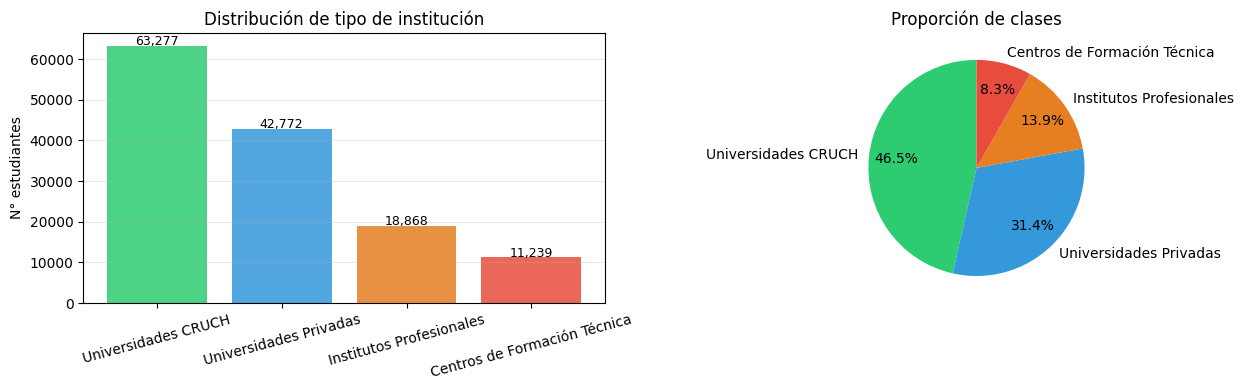

Ratio max/min: 5.6x — desbalance moderado → usar class_weight="balanced"


In [2]:
conteo = df['TIPO_INST_2'].value_counts()
proporciones = df['TIPO_INST_2'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colores_clases = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# Barras
bars = axes[0].bar(conteo.index, conteo.values, color=colores_clases, alpha=0.85)
axes[0].set_title('Distribución de tipo de institución')
axes[0].set_ylabel('N° estudiantes')
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, conteo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{v:,}', ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Torta
axes[1].pie(proporciones.values, labels=proporciones.index,
            autopct='%1.1f%%', colors=colores_clases,
            startangle=90, pctdistance=0.75)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_clf_clases.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = conteo.max() / conteo.min()
print(f'Ratio max/min: {ratio:.1f}x — ', end='')
print('desbalance moderado → usar class_weight="balanced"' if ratio > 2 else 'clases relativamente balanceadas')

## 2. Preparación

In [3]:
TARGET = 'TIPO_INST_2'
feature_cols = [c for c in df.columns if c != TARGET]

# Forzar numérico en todas las features (elimina espacios ' ' residuales)
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=feature_cols)
print(f'Filas tras limpiar valores no numéricos: {len(df):,}')

X = df[feature_cols].values
y = df[TARGET].values

# Codificar etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y)
clases = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Features: {feature_cols}')
print(f'Clases: {list(clases)}')
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')
print()
print('Distribución en test (debe ser similar al total):')
for i, c in enumerate(clases):
    n = (y_test == i).sum()
    print(f'  {c}: {n:,} ({n/len(y_test)*100:.1f}%)')


Filas tras limpiar valores no numéricos: 135,150
Features: ['CLEC_MAX', 'MATE1_MAX', 'PTJE_RANKING', 'INGRESO_PERCAPITA_GRUPO_FA', 'DEPENDENCIA', 'es_tecnico']
Clases: ['Centros de Formación Técnica', 'Institutos Profesionales', 'Universidades CRUCH', 'Universidades Privadas']
Train: 108,120  Test: 27,030

Distribución en test (debe ser similar al total):
  Centros de Formación Técnica: 2,233 (8.3%)
  Institutos Profesionales: 3,742 (13.8%)
  Universidades CRUCH: 12,585 (46.6%)
  Universidades Privadas: 8,470 (31.3%)


## 3. Entrenamiento de modelos

In [4]:
modelos = {
    'Árbol d=5':       DecisionTreeClassifier(max_depth=5, random_state=42,
                                               class_weight='balanced'),
    'Árbol d=10':      DecisionTreeClassifier(max_depth=10, random_state=42,
                                               class_weight='balanced'),
    'Random Forest':   RandomForestClassifier(n_estimators=100, max_depth=10,
                                               random_state=42, n_jobs=-1,
                                               class_weight='balanced'),
    'Reg. Logística':  LogisticRegression(max_iter=500, random_state=42,
                                           class_weight='balanced', n_jobs=-1),
}

resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    reporte = classification_report(y_test, y_pred, target_names=clases,
                                     output_dict=True, zero_division=0)
    macro_f1  = reporte['macro avg']['f1-score']
    weighted_f1 = reporte['weighted avg']['f1-score']
    
    resultados.append({
        'Modelo': nombre, 'Accuracy': acc,
        'F1 macro': macro_f1, 'F1 weighted': weighted_f1
    })
    modelos_entrenados[nombre] = (modelo, y_pred)
    print(f'{nombre:<18}  Acc={acc:.4f}  F1-macro={macro_f1:.4f}  F1-weighted={weighted_f1:.4f}')

df_resultados = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False)
print()
print('Mejor modelo (F1 macro):', df_resultados.iloc[0]['Modelo'])

Árbol d=5           Acc=0.4693  F1-macro=0.3990  F1-weighted=0.4789
Árbol d=10          Acc=0.4926  F1-macro=0.4319  F1-weighted=0.5076
Random Forest       Acc=0.5108  F1-macro=0.4432  F1-weighted=0.5225
Reg. Logística      Acc=0.4397  F1-macro=0.3598  F1-weighted=0.4419

Mejor modelo (F1 macro): Random Forest


## 4. Comparación de métricas

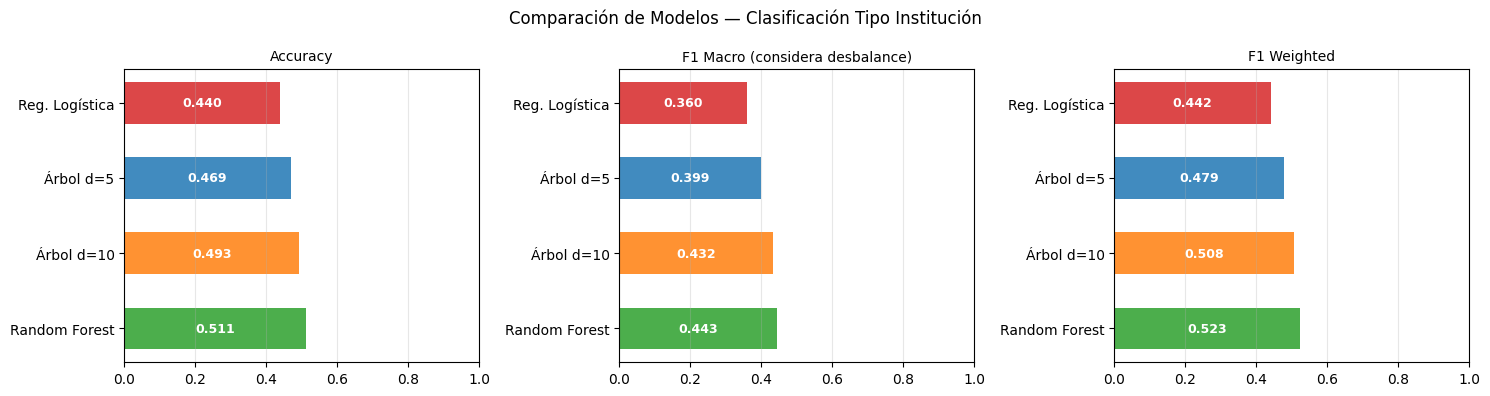

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colores = plt.cm.tab10.colors[:len(modelos)]
etiquetas = df_resultados['Modelo'].tolist()
color_ord = [colores[list(modelos.keys()).index(m)] for m in etiquetas]

for ax, metrica, titulo in zip(axes,
    ['Accuracy', 'F1 macro', 'F1 weighted'],
    ['Accuracy', 'F1 Macro (considera desbalance)', 'F1 Weighted']):
    vals = df_resultados[metrica].values
    bars = ax.barh(etiquetas, vals, color=color_ord, alpha=0.85, height=0.55)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Comparación de Modelos — Clasificación Tipo Institución', fontsize=12)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_clf_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matriz de confusión del mejor modelo

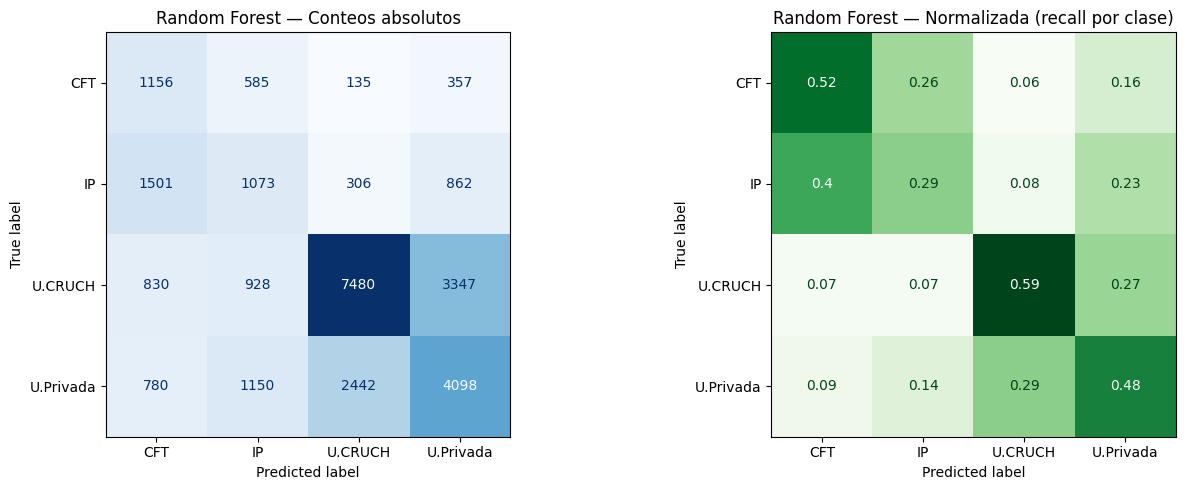

In [6]:
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo, y_pred_mejor = modelos_entrenados[mejor_nombre]

# Nombres cortos para el gráfico
nombres_cortos = ['CFT', 'IP', 'U.CRUCH', 'U.Privada']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteos absolutos
cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(cm, display_labels=nombres_cortos)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{mejor_nombre} — Conteos absolutos')

# Normalizada por fila (precision por clase real)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=nombres_cortos)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'{mejor_nombre} — Normalizada (recall por clase)')

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_clf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(f'Reporte completo — {mejor_nombre}:')
print(classification_report(y_test, y_pred_mejor,
                             target_names=clases, zero_division=0))

Reporte completo — Random Forest:
                              precision    recall  f1-score   support

Centros de Formación Técnica       0.27      0.52      0.36      2233
    Institutos Profesionales       0.29      0.29      0.29      3742
         Universidades CRUCH       0.72      0.59      0.65     12585
      Universidades Privadas       0.47      0.48      0.48      8470

                    accuracy                           0.51     27030
                   macro avg       0.44      0.47      0.44     27030
                weighted avg       0.55      0.51      0.52     27030



## 6. Importancia de variables

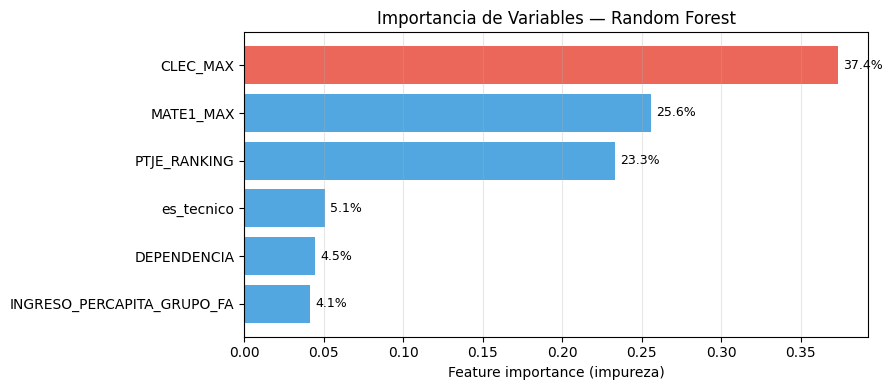

In [8]:
if hasattr(mejor_modelo, 'feature_importances_'):
    imp = mejor_modelo.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_cols, 'importancia': imp})
    imp_df = imp_df.sort_values('importancia', ascending=True)
    total = imp.sum()

    fig, ax = plt.subplots(figsize=(9, 4))
    colores_imp = ['#e74c3c' if v == imp_df['importancia'].max() else '#3498db'
                   for v in imp_df['importancia']]
    bars = ax.barh(imp_df['feature'], imp_df['importancia'],
                   color=colores_imp, alpha=0.85)
    ax.set_xlabel('Feature importance (impureza)')
    ax.set_title(f'Importancia de Variables — {mejor_nombre}')
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, imp_df['importancia']):
        ax.text(v + total * 0.003, bar.get_y() + bar.get_height()/2,
                f'{v/total*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(DATA_PROC / 'fig_clf_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(mejor_modelo, 'coef_'):
    # Logística: coeficientes promedio en valor absoluto por feature
    imp = np.abs(mejor_modelo.coef_).mean(axis=0)
    imp_df = pd.DataFrame({'feature': feature_cols, 'importancia': imp})
    imp_df = imp_df.sort_values('importancia', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(imp_df['feature'], imp_df['importancia'], color='#3498db', alpha=0.85)
    ax.set_xlabel('|Coeficiente| promedio entre clases')
    ax.set_title(f'Importancia de Variables — {mejor_nombre}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_PROC / 'fig_clf_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Tabla final y guardado

In [9]:
print('=' * 65)
print('Resultados finales — Clasificación Tipo de Institución')
print('=' * 65)
print(df_resultados[['Modelo', 'Accuracy', 'F1 macro', 'F1 weighted']].to_string(index=False))
print()
print(f'Baseline (predecir siempre la clase más frecuente — CRUCH 46.5%):')
baseline = (y_test == le.transform(['Universidades CRUCH'])[0]).mean()
print(f'  Accuracy baseline: {baseline:.4f}')
print(f'  Mejor modelo supera baseline en: +{df_resultados.iloc[0]["Accuracy"] - baseline:.4f}')

joblib.dump(mejor_modelo, DATA_PROC / 'modelo_clasificacion.pkl')
joblib.dump(le, DATA_PROC / 'label_encoder_tipo_inst.pkl')
df_resultados.to_csv(DATA_PROC / 'resultados_clasificacion.csv', index=False)

print()
print('Guardado:')
print('  modelo_clasificacion.pkl')
print('  label_encoder_tipo_inst.pkl')
print('  resultados_clasificacion.csv')
print()
print('Figuras:')
for f in sorted(DATA_PROC.glob('fig_clf_*.png')):
    print(f'  {f.name}')

Resultados finales — Clasificación Tipo de Institución
        Modelo  Accuracy  F1 macro  F1 weighted
 Random Forest  0.510803  0.443231     0.522530
    Árbol d=10  0.492638  0.431861     0.507614
     Árbol d=5  0.469293  0.398981     0.478928
Reg. Logística  0.439734  0.359848     0.441924

Baseline (predecir siempre la clase más frecuente — CRUCH 46.5%):
  Accuracy baseline: 0.4656
  Mejor modelo supera baseline en: +0.0452

Guardado:
  modelo_clasificacion.pkl
  label_encoder_tipo_inst.pkl
  resultados_clasificacion.csv

Figuras:
  fig_clf_clases.png
  fig_clf_confusion.png
  fig_clf_importancia.png
  fig_clf_metricas.png


## Resumen P3

| Aspecto | Resultado |
|---------|----------|
| Clases | CFT · IP · U.CRUCH · U.Privada |
| Desbalance | ~5.6x (CRUCH 46% vs CFT 8%) |
| Mejor modelo | (completar) |
| Accuracy | (completar) |
| F1 macro | (completar) |
| Clase más difícil de predecir | (ver matriz de confusión) |

**Próximo paso:** `05_P4_migracion.ipynb`